# AI-Based trash sorting assistant

## <u>What this notebook is about</u>

In this notebook I work step by step on my individual project about building a **Trash Sorting Assistant**. The goal of this project is to classify waste images into the correct category such as cardboard, glass, metal, paper or plastic.

I chose this project because recycling can be confusing in daily life. Sometimes people want to recycle correctly but they are not completely sure in which bin the waste item belongs. With this project I want to create a system that can support the user by analysing an uploaded image and giving a prediction.

The notebook is divided into two main parts. First I clean and prepare the dataset. After that I build a CNN model (I used a pre-trained CNN model) with transfer learning. I also evaluate the model with accuracy, precision, recall, F1-score and a confusion matrix so I can understand how well the model performs for each waste category.

## <u>Data pre-processing</u>

#### 1.0 Importing libraries


In [4]:
from pathlib import Path
import os
import shutil
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

 * Here I import the libraries that I need for the first preprocessing part of the notebook.
 * <u>os</u> and <u>shutil</u> are used for working with files and moving folders, for example when I exclude the trash class.
 * <u>pandas</u> and <u>matplotlib</u> are used to visualise the data in the form of tables and graphs.


#### 2.0 Set the dataset path

In [7]:
trash_dataset = Path("Trash_dataset")

print("Dataset path exists:", trash_dataset.exists())
print("Dataset path:", trash_dataset.resolve())

Dataset path exists: True
Dataset path: C:\Users\alyar\Documents\Sem 4\Trash Sorting Assistant\Trash_dataset


* Here I define where the first trash dataset is located.
* I also print if the folder exists and the full location of the folder.
* I do this as a first safety check because if the path is wrong then the next cells cannot find the images.

#### 3.0 Check which classes are inside the dataset

In [8]:
classes = [folder.name for folder in trash_dataset.iterdir() if folder.is_dir()]

print("Classes found in the dataset:")
for class_name in classes:
    print("-", class_name)

Classes found in the dataset:
- cardboard
- glass
- metal
- paper
- plastic


* In this step I check which classes are inside the trash dataset.
* For image classification every folder name is used as a class label.
* This means that if there is a folder called glass the model will later understand this as one waste category.
* I do this check to see if the dataset contains the classes that I expected and to notice unwanted classes and problems early.

#### 4.0 Count how many images each class has

In [9]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

class_counts = {}

for class_folder in trash_dataset.iterdir():
    if class_folder.is_dir():
        image_files = [
            file for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        ]
        class_counts[class_folder.name] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_counts_df

,Class,Number of Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482


* Here I count here how many image are in each class
* The result is saved in a pandas table so it is easier to read
* This step is important because a model should preferably learn from a balanced dataset. If one class has many more images than another class then the model can become biased toward that class.

#### 5.0 Visualize the class balance

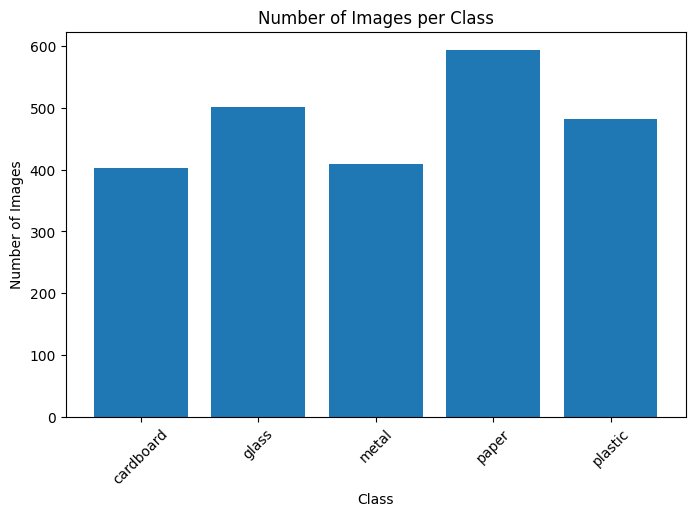

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts_df["Class"], class_counts_df["Number of Images"])
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

This graph shows the amount of images per class. I use a bar chart because it makes it easier to visually compare the classes. This is useful for people who do not know the devision of the dataset because they can immediately see if one class is much bigger or smaller than the others. This helped me decide that the dataset needed cleaning and improving before training the model.

#### 6.0 Remove the trash class

In [11]:
trash_folder = trash_dataset / "trash"
excluded_folder = Path("Excluded_classes")
excluded_folder.mkdir(exist_ok=True)

if trash_folder.exists():
    shutil.move(str(trash_folder), str(excluded_folder / "trash"))
    print("The trash folder has been moved to Excluded_classes.")
else:
    print("Trash folder was already removed or does not exist.")

Trash folder was already removed or does not exist.


In this step I remove the <u>trash</u> class from the training dataset. I do not delete it permanently instead I move it to the <u>Excluded_classes</u> folder. I did this because the trash class contained mixed images from other categories so it could confuse the model.For example if the trash folder contains plastic, metal and paper together the model would not learn one clear category from it. By excluding this class the final dataset becomes cleaner and less biased.

#### 7.0 Check the class counts after removing trash class

In [12]:
class_counts_after_removal = {}

for class_folder in trash_dataset.iterdir():
    if class_folder.is_dir():
        image_files = [
            file for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        ]
        class_counts_after_removal[class_folder.name] = len(image_files)

class_counts_after_df = pd.DataFrame(
    list(class_counts_after_removal.items()),
    columns=["Class", "Number of Images"]
)

class_counts_after_df

,Class,Number of Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482


After moving the trash class I checked again the count the images. This is a check to confirm that the unwanted class is no longer part of the training dataset. I do this because preprocessing should always be checked after making changes. The table now shows only the classes that are still used in the project.

### 8.0 Dataset Overview

After checking the dataset I found that the images are divided into folders where each folder represents a waste category. This means the dataset is already structured for an image classification problem.

The original dataset contained six classes: cardboard, glass, metal, paper, plastic, and trash.  
I decided to remove the trash class because it is not a clear material category. It contains mixed waste items and overlaps with the other classes, which can make the model less accurate.

For the first version of my Trash Sorting Assistant I will continue with five clear classes:

- cardboard
- glass
- metal
- paper
- plastic

These classes are easier to distinguish and better suited for training a first image classification model.

## <u>Dataset extending</u>

#### 1.0 dataset path setting 

In [5]:
dataset_path = Path("Trash dataset 2")

print("Dataset exists:", dataset_path.exists())
print("Dataset location:", dataset_path.resolve())

Dataset exists: False
Dataset location: C:\Users\alyar\Documents\Sem 4\Trash Sorting Assistant\model\Trash dataset 2


Here I set the path to the second dataset. This is the cleaned and extended dataset called **Trash dataset 2**. I print the location again to make sure that the notebook is using the correct dataset.

#### 2.0 checking which classes are inside 

In [7]:
classes = [folder.name for folder in dataset_path.iterdir() if folder.is_dir()]

print("Classes found in the dataset:")
for class_name in classes:
    print("-", class_name)

Classes found in the dataset:
- cardboard
- glass
- metal
- paper
- plastic


In this step I check the classes in the extended dataset. This is important because these folder names will become the waste categories that the CNN model needs to predict. For my project the important classes are cardboard, glass, metal, paper and plastic. This check helps me confirm that excluded class(trash) is not accidentally used for training.

#### 3.0 count of images per cathegory

In [10]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

class_counts = {}

for class_folder in dataset_path.iterdir():
    if class_folder.is_dir():
        image_files = [
            file for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        ]
        class_counts[class_folder.name] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_counts_df

,Class,Number of Images
0,cardboard,600
1,glass,600
2,metal,599
3,paper,600
4,plastic,600


Here I displayed the count of the images per class. I use this step to check if the dataset is balanced after extending it with extra and augmented images, on this way it gives me a clear overview.A balanced dataset helps the model learn every waste category more fairly.

#### 4.0 class balance in graph

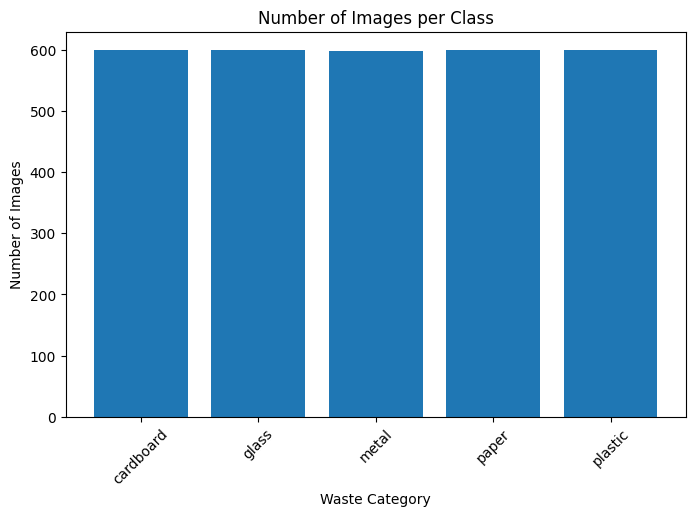

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts_df["Class"], class_counts_df["Number of Images"])
plt.title("Number of Images per Class")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

This graph shows the amount of images per class.The goal is to quickly see if every waste category has around the same number of images. This is useful because a table gives exact numbers but a graph makes differences easier to notice. If the bars are almost the same height then the dataset is balanced enough for training.

#### 5.0 total amount of images

In [12]:
total_images = class_counts_df["Number of Images"].sum()

print("Total number of images:", total_images)

Total number of images: 2999


Here I calculate the total number of images in the dataset. This tells me how much data I have available for training, validation and testing. Knowing the total amount of images is useful because CNN models need enough examples to learn visual patterns.

#### 6.0 check if the dataset is balanced

In [13]:
min_images = class_counts_df["Number of Images"].min()
max_images = class_counts_df["Number of Images"].max()

print("Smallest class:", min_images, "images")
print("Largest class:", max_images, "images")

if min_images == max_images:
    print("The dataset is balanced.")
else:
    print("The dataset is not fully balanced.")

Smallest class: 599 images
Largest class: 600 images
The dataset is not fully balanced.


In this step I compare the smallest and largest class. The amount of the images are slightly different in this dataset but this is not a problem and can be counted as a balanced dataset. I use this check because class balance is important for fair classification results.

#### 7.0 Excluding broken images

In [ ]:
from pathlib import Path
import shutil

project_root = Path(".")

# metalbroken image location
broken_image_path = project_root / "Trash dataset 2" / "metal" / "aug_metal_0116.jpg"

#excluded classes folder + new broken image folder
broken_images_folder = project_root / "Excluded_classes" / "broken_images"
broken_images_folder.mkdir(parents=True, exist_ok=True)
destination_path = broken_images_folder / "aug_metal_0116.jpg"

# moving the broken image
if broken_image_path.exists():
    shutil.move(str(broken_image_path), str(destination_path))
    print(f"Broken image moved to: {destination_path}")
elif destination_path.exists():
    print(f"Broken image is already in the excluded folder: {destination_path}")
else:
    print("Broken image was not found in the metal folder or excluded folder.")

Broken image is already in the excluded folder: Excluded_classes\broken_images\aug_metal_0116.jpg


Here I move the broken image (aug_metal_0116.jpg) from the metal class to the Excluded_classes/broken_images folder. I move it instead of deleting it so I can still show that this image was excluded during preprocessing. Broken images can cause errors during model training because TensorFlow cannot read them correctly. By excluding the broken image the training process becomes more stable and the dataset stays clean.

#### Dataset Balance explanation

After loading the new dataset I checked how many images are available in each class.  
This step is important because a balanced dataset helps the model learn each category more fairly.

If one class has much more images than another class the model can become biased toward the larger class.  
That means the model may predict that class more often even when the image belongs to another category.

For this project I want to use a balanced dataset with five clear waste categories: cardboard, glass, metal, paper, and plastic.  
The **trash** class is not used because it contains mixed waste items and overlaps with the other categories.

## CNN model with transfer learning

* In this part of the notebook I start with the modelling part of the Trash Sorting Assistant.Herefore I will use a CNN model with transfer learning. This means that I will use a model that was already pretrained on many real-world images and then adapt it to my own trash dataset. This is useful because my dataset contains real object images such as cardboard, glass, metal, paper and plastic and pretrained CNN models are already good at recognizing visual patterns like shapes, colors and textures.
* The model I will start with is **EfficientNetB0** . I chose this model because it is not too heavy, it works well for image classification and it can also be finetuned later if the first results need improvement.

#### 1.0 Importing libraries 

In [14]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Here I import the libraries that are needed for the modelling part.
* numpy -> for numerical operations, when selecting the class with the highest prediction score
* tensorflow and keras -> used to build, train and evaluate the CNN model
* EfficientNetB0 = pretrained model used for transfer learning
* EarlyStopping and ModelCheckpoint = callbacks that help control the training process and save the best version of the model


Here I installed the TensorFlow in the notebook environment because it is the main library used to train the CNN model. 


In [15]:
%pip install --upgrade pip
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#### 2.0  Set the CNN model settings




In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

class_names = sorted([folder.name for folder in dataset_path.iterdir() if folder.is_dir()])
num_classes = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Image size: (224, 224)
Batch size: 32
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Number of classes: 5


Before training the model I define the most important settings for the CNN. All images are resized to 224 by 224 pixels which means that every image is resized before it is given to the model. I also define the batch size=32 (the model processes 32 images at a time during training) and seed=42 (helps make the data split more consistent if the notebook is run again). 

#### 3.0 Collect image paths and labels from the cleaned dataset


In [17]:
image_paths = []
labels = []

valid_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for class_folder in sorted(dataset_path.iterdir()):
    if class_folder.is_dir():
        class_name = class_folder.name
        
        for image_file in class_folder.iterdir():
            if image_file.suffix.lower() in valid_extensions:
                image_paths.append(str(image_file))
                labels.append(class_name)

print("Total images collected:", len(image_paths))
print("Classes collected:", sorted(set(labels)))

Total images collected: 2999
Classes collected: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


* The dataset was already cleaned in the preprocessing part. In this step I only collect the image paths and the matching class labels from the existing cleaned dataset.
* This is needed because the model needs two things for every image: where the image can be found and what the correct category is.

The image path tells the notebook where each image is stored. The label tells the notebook which category the image belongs to, for example glass or paper. In simple words, I am creating a list of pictures together with their correct answers, so the model can learn from them later.

#### 4.0 Convert class labels to numbers


In [18]:
label_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_label = {index: class_name for class_name, index in label_to_index.items()}

numeric_labels = [label_to_index[label] for label in labels]

print("Label mapping:")
for class_name, index in label_to_index.items():
    print(class_name, "=", index)

Label mapping:
cardboard = 0
glass = 1
metal = 2
paper = 3
plastic = 4


CNN models cannot directly train with text labels such as cardboard, glass or plastic.That is why I convert every class name to a number. For example cardboard becomes 0, glass becomes 1 and so on. I also keep the mapping between numbers and class names so the model predictions can later be translated back into readable waste categories.

#### 5.0 Data splitting (train, validation, test)




In [ ]:
from sklearn.model_selection import train_test_split

# 1st spli t=  70% training + 30% temporary data
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    numeric_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=numeric_labels
)

# 2nd split = 15% val + 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 2099
Validation images: 450
Test images: 450


For modelling I split the data into three parts:

- Training set: used to train the model
- Validation set: used during training to check if the model improves
- Test set: used after training to evaluate the final model on unseen images

The first split keeps 70% of the images for training and sets 30% aside temporarily. The temporary 30% is then split into two equal parts: 15% validation and 15% test. This is why the code first uses test_size=0.30 and then test_size=0.50 on the temporary data.

I also use stratify, which keeps the class distribution similar in every split. This is important because each waste category should be represented fairly in the training, validation and test sets.

#### 6.0  Creating TensorFlow dataset


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    
    # resizing the images to keep proportion better 
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    
    # efficientnet can work with pixel values from 0 to 255
    image = tf.cast(image, tf.float32)
    
    return image, label


def create_dataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=SEED)
        
    dataset = dataset.map(load_and_prepare_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset


train_ds = create_dataset(train_paths, train_labels, shuffle=True)
val_ds = create_dataset(val_paths, val_labels, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, shuffle=False)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In this step I convert the image paths and labels into TensorFlow datasets. TensorFlow reads the images, resizes them and groups them into batches. I use resizing with padding because the original images are rectangular. 

The function reads each image file, decodes it as an RGB image, resizes it with padding and returns the image together with its label. Batching groups images together and on this way it makes training more efficient. Prefetching prepares the next batch while the model is already training so the process runs more smoothly.

#### 7.0 Adding data augmentation


In [28]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation layer created.")

Data augmentation layer created.


Data augmentation creates small variations of the training images. For example images can be flipped, slightly rotated, zoomed or adjusted in contrast. This is useful because waste items in real life can be photographed from different angles, distances and lighting situations. I only apply augmentation during training, not during validation or testing because validation and test data should stay unchanged for fair evaluation.

#### 8.0 Build the EfficientNetB0 transfer learning model


In [29]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import models, layers

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

# freezing the pretrained base model (1st round)
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In this step I build the CNN model using EfficientNetB0 as the pretrained base model. The pretrained base has already learned general image features from many real-world images. For the first training round I freeze this base model so its existing layers do not change yet. I only train the new layers that I add on top for my own five waste categories.

#### 9.0 Compile the model


In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


Before training the model needs to be compiled. Compiling tells TensorFlow how the model should learn and how performance should be measured. I use the Adam optimizer because it is commonly used and works well for many deep learning tasks. I use sparse_categorical_crossentropy because this is a multi-class classification problem and the labels are stored as numbers. I keep accuracy as a training metric because it gives a quick overview of how often the model predicts correctly during training.

Accuracy is useful during training but it is not enough for the final evaluation. That is why I also use precision, recall, F1-score and a confusion matrix later in the notebook.

#### 10.0 Training the model 


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)

checkpoint_path = models_folder / "efficientnetb0 first model.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

EPOCHS_FIRST = 10

history_first = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FIRST,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.4925 - loss: 1.2384
Epoch 1: val_accuracy improved from None to 0.76000, saving model to models\efficientnetb0_first_best.keras

Epoch 1: finished saving model to models\efficientnetb0_first_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.6127 - loss: 0.9973 - val_accuracy: 0.7600 - val_loss: 0.6575
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7758 - loss: 0.6485
Epoch 2: val_accuracy improved from 0.76000 to 0.80444, saving model to models\efficientnetb0_first_best.keras

Epoch 2: finished saving model to models\efficientnetb0_first_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 418ms/step - accuracy: 0.7932 - loss: 0.6016 - val_accuracy: 0.8044 - val_loss: 0.5411
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8319 - loss: 0.5035
Epoch 3: val_accuracy improved from 0.80444 to 0.82222, saving model to models\efficientnetb0_first_best.keras

Epoch 3: finished saving mo

Here I train the first version of the model. In this first training round the EfficientNetB0 base model stays frozen. This means only the new classification layers on top are trained on my trash dataset. I use EarlyStopping to stop training when the validation loss no longer improves and ModelCheckpoint to save the best model during training. I set a maximum of 10 epochs, but the training can stop earlier if the model stops improving.

### **Results**

#### 11.0 Plot for training accuracy and val accuracy

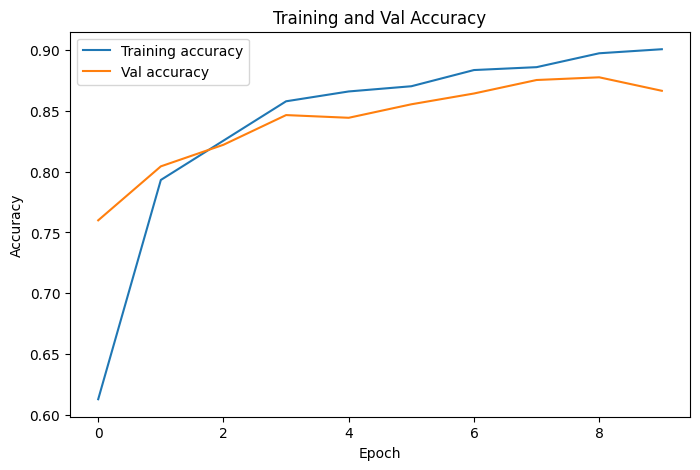

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history_first.history["accuracy"], label="Training accuracy")
plt.plot(history_first.history["val_accuracy"], label="Val accuracy")
plt.title("Training and Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

* Training accuracy= how well the model performs on the images it learns from
* Validation accuracy= how well the model performs on images that are not directly used for training

In this graph both the training accuracy and validation accuracy increase over the epochs so the model is learning from the trash dataset.

The validation accuracy stays close to the training accuracy so the model is not only learning the training images but can also make good predictions on images it has not seen before.

The training accuracy is a bit higher than the validation accuracy which is normal. At the end the validation accuracy goes a little bit down while the training accuracy still increases. This is a small sign that the model is starting to overfit but the difference is not very big.




#### 12.0 Plot for training loss and val loss

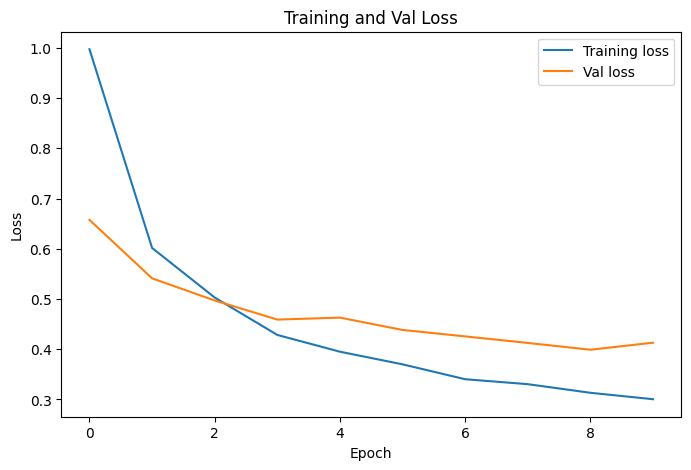

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_first.history["loss"], label="Training loss")
plt.plot(history_first.history["val_loss"], label="Val loss")
plt.title("Training and Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In this graph I compare the training loss and validation loss.  
* Loss =how wrong the model predictions are (lower loss ->the model is making better predictions)

The training loss decreases from around 1.00 to around 0.30, and the validation loss decreases from around 0.66 to around 0.40. This shows that the model is learning and making fewer mistakes over the epochs.

I use this graph together with the accuracy graph to understand the learning behaviour of the model. At the end the validation loss increases slightly while the training loss still decreases. This is a small sign that the model is starting to overfit a little bit but the difference is not very big.


#### 13.0 Evaluation of the model on the test set

In [36]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Test accuracy percentage:", round(test_accuracy * 100, 2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - accuracy: 0.8733 - loss: 0.3575
Test loss: 0.3575
Test accuracy: 0.8733
Test accuracy percentage: 87.33 %


In this step I evaluate the model on the test set.  
The test set contains images that the model has not seen before so it shows how well the model works on new data.

The model reached a test accuracy of 87.33% so it predicted around 87 out of 100 test images correctly.  
The test loss is 0.3575 which is quite low and so the model is making good predictions.


#### 14.0 Precision, recall, F1-score and confusion matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# true label from test set
y_true = np.array(test_labels) 

#  probab for test image
y_pred_probabilities = model.predict(test_ds)

# convert probab to predicted class numbers
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 540ms/step
Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.83      0.89        90
       glass       0.81      0.96      0.88        90
       metal       0.88      0.86      0.87        90
       paper       0.85      0.86      0.85        90
     plastic       0.91      0.87      0.89        90

    accuracy                           0.87       450
   macro avg       0.88      0.87      0.87       450
weighted avg       0.88      0.87      0.87       450



This classification report shows how well the model performs for each waste category separately. 
* Accuracy= gives one general score but it does not show how the model performs for each separate waste category 
* Precision=  how many images predicted as a certain class were actually correct
* Recall= how many real images from a class were found correctly by the model 
* F1-score= combines precision and recall into one balanced score.

The model reached an overall accuracy of 87% on the test set. The test set contains 450 images with 90 images for each class so the results are balanced.

The F1-scores are close to each other between 0.85 and 0.89. This means that the model does not only perform well for one class but it performs quite stable for all categories. Cardboard and plastic have the highest F1-score of 0.89. Paper has the lowest F1-score of 0.85 so this category is a little bit more difficult for the model.


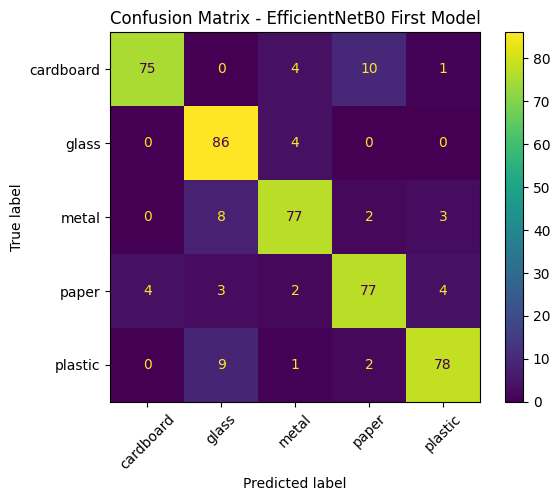

In [38]:

cm = confusion_matrix(y_true, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(values_format="d")
plt.title("Confusion Matrix - EfficientNetB0 First Model")
plt.xticks(rotation=45)
plt.show()

This confusion matrix shows which classes the model predicted correctly and which classes it confused.

The values on the diagonal are the correct predictions. For example the model correctly predicted 75 cardboard images, 86 glass images, 77 metal images, 77 paper images and 78 plastic images.

The model performs best on glass, where 86 out of 90 images were predicted correctly. Cardboard was sometimes confused with paper because 10 cardboard images were predicted as paper. Plastic and metal were also sometimes confused with glass which can happen because some waste items can look visually similar depending on the shape, color or lighting.


### **Fine-tuning**

#### 15.0 Fine-tuning the model


In [ ]:
# unfreezing the base model
base_model.trainable = True

# freezing most layers and only fine-tune the last part
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total layers in base model:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

Total layers in base model: 238
Fine-tuning from layer: 208


After training the first model I fine-tune it to see if the performance can improve.

* Fine-tuning means that I unfreeze a small part of the pretrained EfficientNetB0 base model and train it again with a very small learning rate. In this project I keep most of the pretrained base frozen and only allow the last 30 layers to update.

* I do this because the earlier layers usually learn very general patterns such as edges, colours and simple textures. The later layers are more specific so they can adapt better to my waste images.

In [42]:
#smaller learning rate for fine-tuning

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled for fine-tuning.")

Model compiled for fine-tuning.


I use a very small learning rate of 0.00001 because during fine-tuning some layers of the pretrained model are unfrozen. So these layers already contain useful knowledge from the pretrained model so I do not want to change them too much or too quickly.
The loss function stays sparse_categorical_crossentropy because this is still a multi-class classification problem with numeric labels. The metric stays accuracy so I can follow how well the model performs during fine-tuning.

#### 16.0 Train the fine-tuned model

In [ ]:
fine_tune_checkpoint_path = models_folder / "efficientnetb0 finetuned model.keras"

fine_tune_checkpoint = ModelCheckpoint(
    filepath=str(fine_tune_checkpoint_path),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

EPOCHS_FINE = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=[early_stopping, fine_tune_checkpoint]
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8141 - loss: 0.5538
Epoch 1: val_accuracy improved from None to 0.85778, saving model to models\efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to models\efficientnetb0_finetuned_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 504ms/step - accuracy: 0.8294 - loss: 0.5299 - val_accuracy: 0.8578 - val_loss: 0.4082
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8522 - loss: 0.4846
Epoch 2: val_accuracy did not improve from 0.85778
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 442ms/step - accuracy: 0.8571 - loss: 0.4751 - val_accuracy: 0.8489 - val_loss: 0.4239
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8531 - loss: 0.4432
Epoch 3: val_accuracy did not improve from 0.85778
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 434ms/step - accuracy: 0.8576 - loss: 0.4435 - val_accuracy: 0.8400 - val_loss: 0.4344
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8633 - loss: 0.4468
Epoch 4: val_a


I use ModelCheckpoint to save only the best version of the model based on val accuracy.  
I trained the model for 5 epochs and only the unfrozen layers are updated. This helps the pretrained model adapt more to my trash dataset but in a controlled way. I used also early stopping to prevent the model from training too long if the val result stops improving.

### **Results fine-tuning**

#### 17.0 Evaluation on the fine-tuned model on the test set 

In [44]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print("Fine-tuned test loss:", round(fine_test_loss, 4))
print("Fine-tuned test accuracy:", round(fine_test_accuracy, 4))
print("Fine-tuned test accuracy percentage:", round(fine_test_accuracy * 100, 2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.8778 - loss: 0.3652
Fine-tuned test loss: 0.3652
Fine-tuned test accuracy: 0.8778
Fine-tuned test accuracy percentage: 87.78 %


* The test accuracy  before the fine-tuning was 87.33% and a test loss was 0.3575.  
After fine-tuning the model reached a test accuracy of 87.78% and a test loss of 0.3652.
This means that the accuracy improved slightly by 0.45. So the fine-tuned model predicted a few more test images correctly. 
* However the test loss became slightly higher from 0.3575 to 0.3652. This means that fine-tuning did not clearly improve the model.

Overall both models perform well on unseen trash images. The fine-tuned model gives a small accuracy improvement but the difference is not very big. So the transfer learning modelbefore the fine-tuning was already strong and fine-tuning only helped a little bit.

### **Results**

#### 18.0 Precision, recall, F1-score and confusion matrix

In [ ]:
from sklearn.metrics import classification_report

# true label from test set
y_true = np.array(test_labels)

#probab for test image
fine_y_pred_probabilities = model.predict(test_ds)

# Convert probab to predicted class numbers
fine_y_pred = np.argmax(fine_y_pred_probabilities, axis=1)

print("Classification Report - Fine-tuned EfficientNetB0:")
print(classification_report(y_true, fine_y_pred, target_names=class_names))

15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 469ms/step
Classification Report - Fine-tuned EfficientNetB0:
              precision    recall  f1-score   support

   cardboard       0.95      0.84      0.89        90
       glass       0.81      0.93      0.87        90
       metal       0.87      0.84      0.86        90
       paper       0.88      0.88      0.88        90
     plastic       0.90      0.89      0.89        90

    accuracy                           0.88       450
   macro avg       0.88      0.88      0.88       450
weighted avg       0.88      0.88      0.88       450



* The model without fine-tuning had an overall accuracy of 87% and after fine-tuning the accuracy became 88% so it gave a small improvement. 
* The macro average F1-score also improved from 0.87 to 0.88 which means the model became slightly more balanced over all classes.

* The biggest improvement is for the paper class. Before fine-tuning paper had an F1-score of 0.85 and after fine-tuning it improved to 0.88. Plastic also improved a little in recall from 0.87 to 0.89.

* However not every class improved. Glass went from an F1-score of 0.88 to 0.87 and metal went from 0.87 to 0.86. This shows that fine-tuning helped some classes but slightly reduced the performance for others.

* The fine-tuned model performed a little bit better than without it but the difference is small. The model is still stable because all classes have an F1-score between 0.86 and 0.89.

#### 19.0 Confusion matrix 

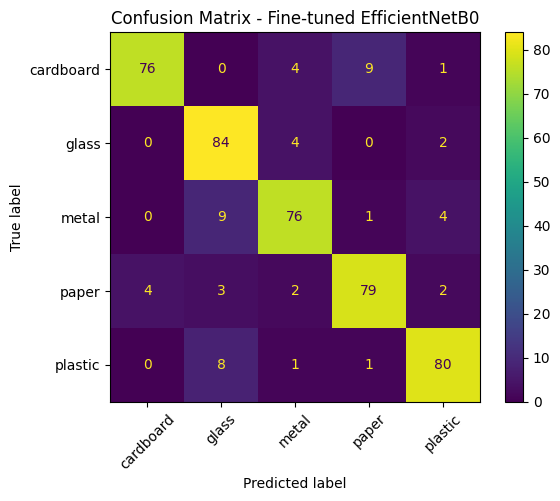

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fine_cm = confusion_matrix(y_true, fine_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=fine_cm,
    display_labels=class_names
)

display.plot(values_format="d")
plt.title("Confusion Matrix - Fine-tuned EfficientNetB0")
plt.xticks(rotation=45)
plt.show()

Most predictions are again on the diagonal which means that the model predicts most images correctly.  
Difference between the non-fine-tuned model and the fine tuned model:

- 75 -> 76 cardboard 
- 86 ->84 glass 
- 77-> 76 metal 
- 77 ->79 paper 
- 78 ->80 plastic 

Compared to the model without the fine-tuning the total number of correct predictions improved from 393 to 395 out of 450 test images. The model still makes mistakes between classes that look similar like metal and plastic are sometimes predicted as glass, cardboard and paper.


#### 20.0 Plot for accuracy and loss

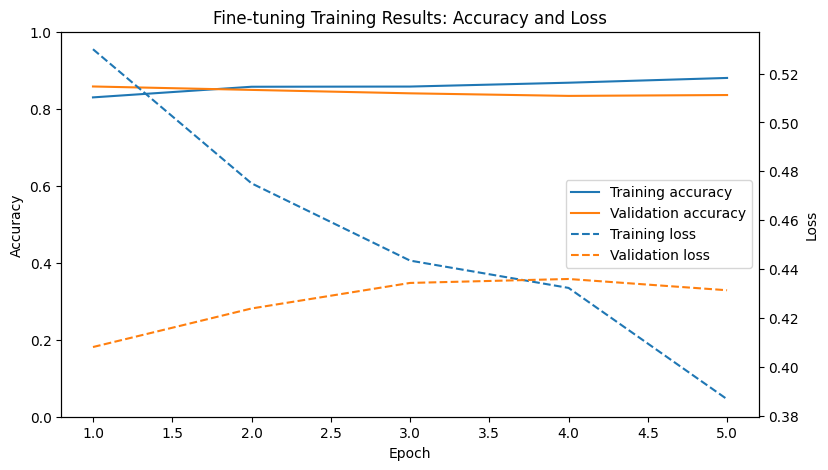

In [ ]:
epochs = range(1, len(history_fine.history["accuracy"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))

#accuracy
ax1.plot(epochs, history_fine.history["accuracy"], label="Training accuracy")
ax1.plot(epochs, history_fine.history["val_accuracy"], label="Validation accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1)

#loss
ax2 = ax1.twinx()
ax2.plot(epochs, history_fine.history["loss"], linestyle="--", label="Training loss")
ax2.plot(epochs, history_fine.history["val_loss"], linestyle="--", label="Validation loss")
ax2.set_ylabel("Loss")

#combining
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.title("Fine-tuning Training Results: Accuracy and Loss")
plt.show()

* The training accuracy increases slightly so this means that the model is still learning from the training images. 
* The val accuracy stays the same and does not improve much during fine-tuning.

* The training loss decreases clearly and this means that the model is becoming more confident on the training data. 
* The val loss first increases a little bit and then becomes slightly lower again at the end.

The fine-tuning helped the model learn the training data better but the validation results did not improve a lot. This means that the first transfer learning model was already quite strong, and fine-tuning only gave a small improvement.

#### 21.0 Predicting one image  (test)

In [48]:
def predict_waste_image(image_path):
    image_path = str(image_path)
    
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.cast(image, tf.float32)
    
    image_batch = tf.expand_dims(image, axis=0)
    
    predictions = model.predict(image_batch)
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index] * 100
    predicted_class = class_names[predicted_index]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.show()
    
    print("Predicted class:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")
    
    return predicted_class, confidence

Here I created a small test function to check if the trained model can make a prediction on one image. The function takes an image path, loads the image, resizes it to the same size that was used during training and then sends it to the model. The model then predicts which waste category the image belongs to and also gives a confidence percentage.

I use an image from the test set by selecting an index, for example example_image = test_paths[11]. This means that the model predicts one image that it has not seen during training. The function then shows the image together with the predicted class and confidence score.

This is useful because it lets me check the model in a more practical way. Instead of only looking at metrics like accuracy and F1-score I can also see if the model gives a logical prediction for a real image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step


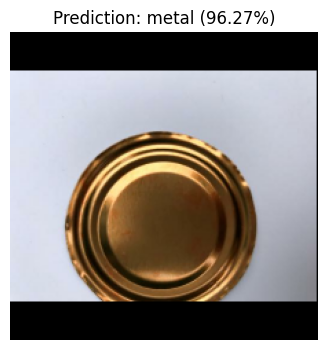

Predicted class: metal
Confidence: 96.27 %


('metal', np.float32(96.27314))

In [62]:
# Example test image from the test set
example_image = test_paths[11]

predict_waste_image(example_image)

In [31]:
import json

with open("class_names.json", "w") as f:
    json.dump([str(name) for name in class_names], f, indent=4)

print("class_names.json created successfully!")
print(class_names)

class_names.json created successfully!
['cardboard', 'glass', 'metal', 'paper', 'plastic']


## **Data extending 3**

In this part I create a third version of my dataset: **Trash dataset 3**.  
The reason why I do this is because I want the model to see more examples of the same waste categories. In real life people do not always take clean and perfect pictures. Sometimes the picture is darker, brighter, a bit rotated, zoomed in or taken from another angle. By creating extra versions of the images I try to make the model more prepared for these real-life situations.

I still keep the same classes, for example cardboard, glass, metal, paper and plastic. So I am not changing the meaning of the images. I am only making extra variations of the existing images.


#### 1.0 Dataset location setting

Here I set the location of the current dataset and the new dataset.  
**Trash dataset 2** is the dataset that I already cleaned and used before. **Trash dataset 3** will be the new extended version. In this new folder I will copy the original images and also add new augmented images.

I also set how many new images I want to create per original image. In this case I use 4 augmented images per original image. I use a random seed so the random changes are more controlled and can be repeated again when I run the notebook.


In [32]:
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import random
import shutil

# current dataset
original_dataset_path = Path("Trash dataset 2")

# extended dataset
extended_dataset_path = Path("Trash dataset 3")

# amount of the new augmented images per original image
AUGMENTATIONS_PER_IMAGE = 4

image_extensions = [".jpg", ".jpeg", ".png"]

random.seed(42)

# new dataset folder
extended_dataset_path.mkdir(exist_ok=True)

print("Original dataset:", original_dataset_path)
print("Extended dataset:", extended_dataset_path)

Original dataset: Trash dataset 2
Extended dataset: Trash dataset 3


#### 2.0 Adding the augmented functions

In this code I create small functions that change the image a little bit. These functions are used to make the dataset more realistic. For example a user can take a photo of trash in a dark room, outside in bright light or from a strange angle.

The important thing is that the waste category stays the same. A plastic bottle is still plastic, even when the image is a bit darker or rotated. That is why these changes are useful for training the model: the model learns to focus more on the object itself and less on perfect photo conditions.


In [33]:
def change_lighting(image):
    """
    Changes brightness to simulate darker or brighter environments.
    """
    factor = random.uniform(0.6, 1.5)
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(factor)


def change_contrast(image):
    """
    Changes contrast to simulate different light conditions.
    """
    factor = random.uniform(0.7, 1.4)
    enhancer = ImageEnhance.Contrast(image)
    return enhancer.enhance(factor)


def rotate_image(image):
    """
    Rotates the image to simulate a different camera angle.
    """
    angle = random.uniform(-25, 25)
    return image.rotate(angle, expand=True, fillcolor=(255, 255, 255))


def zoom_image(image):
    """
    Slightly zooms to the object.
    """
    width, height = image.size

    zoom_factor = random.uniform(0.85, 0.95)

    new_width = int(width * zoom_factor)
    new_height = int(height * zoom_factor)

    left = random.randint(0, width - new_width)
    top = random.randint(0, height - new_height)

    cropped = image.crop((left, top, left + new_width, top + new_height))
    return cropped.resize((width, height))


def flip_image(image):
    """
    Flips the image horizontally.
    """
    return ImageOps.mirror(image)


def apply_random_augmentation(image):
    """
    Applies a random combination of augmentations.
    """
    augmented = image.copy()

    transformations = [
        change_lighting,
        change_contrast,
        rotate_image,
        zoom_image,
        flip_image
    ]

    selected_transformations = random.sample(transformations, random.randint(2, 3))

    for transform in selected_transformations:
        augmented = transform(augmented)

    return augmented

#### 3.0 Creating the extended dataset

Here I actually create **Trash dataset 3**. The code goes through every class folder in Trash dataset 2. 
* For each image it first copies the original image to the new dataset. 
* After that it creates the extra augmented images and saves them in the same class folder.

I do this so the new dataset still has the same structure as before. For example all plastic images stay inside the plastic folder and all glass images stay inside the glass folder. This is important because later the folder names are used as the labels for the model.


In [ ]:
total_original = 0
total_augmented = 0

for class_folder in original_dataset_path.iterdir():
    if not class_folder.is_dir():
        continue

    class_name = class_folder.name
    output_class_folder = extended_dataset_path / class_name
    output_class_folder.mkdir(parents=True, exist_ok=True)

    image_files = [
        file for file in class_folder.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    print(f"Processing class: {class_name} | Images found: {len(image_files)}")

    for image_file in image_files:
        try:
            image = Image.open(image_file).convert("RGB")

            # saving the original image also to the new dataset
            original_output_path = output_class_folder / image_file.name
            shutil.copy(image_file, original_output_path)
            total_original += 1

            # creating the augmented images
            for i in range(AUGMENTATIONS_PER_IMAGE):
                augmented_image = apply_random_augmentation(image)

                new_file_name = f"aug_extra_{image_file.stem}_{i+1}.jpg"
                new_output_path = output_class_folder / new_file_name

                augmented_image.save(new_output_path, quality=95)
                total_augmented += 1

        except Exception as e:
            print(f"Could not process image: {image_file}")
            print("Error:", e)

print("Finished extending dataset!")
print("Original images copied:", total_original)
print("New augmented images created:", total_augmented)
print("Total images in extended dataset:", total_original + total_augmented)

Processing class: cardboard | Images found: 600
Processing class: glass | Images found: 600
Processing class: metal | Images found: 599
Processing class: paper | Images found: 600
Processing class: plastic | Images found: 600
Finished extending dataset!
Original images copied: 2999
New augmented images created: 11996
Total images in extended dataset: 14995


* We can see now that the dataset is extended dataset 2 had 2999 images in total and now dataset 3 has 14995 images.

#### 4.0 Checking how many images are there per class

After creating the new dataset I check how many images each category has. This helps me see if the extension worked correctly and if every class received extra images.

This step is also useful because an unbalanced dataset can make the model biased. For example if one class has much more images than the others then the model can become better at predicting that class and weaker at predicting the smaller classes.


In [35]:
from collections import Counter

class_counts = {}

for class_folder in extended_dataset_path.iterdir():
    if class_folder.is_dir():
        count = len([
            file for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        ])
        class_counts[class_folder.name] = count

class_counts

{'cardboard': 3000,
 'glass': 3000,
 'metal': 2995,
 'paper': 3000,
 'plastic': 3000}

* We can see now that the amount of images per class went from 600 to 3000.

### 5.0 Preparing the dataset settings

In this part I set the basic settings that I will use when working with the dataset.

* First I set the image size to **224 by 224 pixels** (makes all the images on the same size)

* I also set the batch size to **32**= the model will look at 32 images at a time during training => more efficient

* The seed is set to **42**. I use this so that the random parts of the notebook for example splitting the data stay the same every time I run it.




In [36]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Dataset path:", extended_dataset_path)
print("Dataset exists:", extended_dataset_path.exists())

Dataset path: Trash dataset 3
Dataset exists: True


#### 6.0 Installing the needed libraries

In this part I import the libraries that I need for the next steps. 
* train_test_split function = used to divide the dataset into training, validation and test 


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#### 7.0 Splitting the dataset to train, validation and test sets

Here I split the images into three parts. 
* The training set is used by the model to learn. 
* The validation set is used during training to check if the model is improving. 
* The test set is only used at the end to evaluate the model on images it did not train on.

I use a 70/15/15 split. This means 70% is for training, 15% for validation and 15% for testing. 


In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

# 70% for training
# 15% for validation 
# 15% for testing

Train images: 10496
Validation images: 2249
Test images: 2250


#### 8.0 Creating a TensorFlow dataset

In this part I prepare the images in a way that TensorFlow can use them. The images can have different sizes so I resize them to 224 x 224 pixels.

I created also batches so the model does not train on one image at a time but that it will train on a small groups of images. 

I also use prefetching so the training process can run smoother because TensorFlow can prepare the next batch while the model is training on the current batch.


In [41]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)

    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1])
    image = tf.cast(image, tf.float32)

    return image, label


def create_dataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=SEED)
    
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset


train_dataset = create_dataset(train_paths, train_labels, shuffle=True)
val_dataset = create_dataset(val_paths, val_labels, shuffle=False)
test_dataset = create_dataset(test_paths, test_labels, shuffle=False)

#### 9.0 Load the EfficientNet fine-tuned model

Here I load the fine-tuned EfficientNetB0 model that I already trained before. The model already learned useful patterns from the previous dataset (dataset 2) and now I can continue training it with the larger Trash dataset 3. This is useful because the model can improve with the new variations without losing all the learning it already did before.


In [44]:
models_folder = Path("models")

existing_model_path = models_folder / "efficientnetb0 finetuned model.keras"

model = tf.keras.models.load_model(existing_model_path, compile=False)

print("Existing fine-tuned model loaded successfully!")
model.summary()

Existing fine-tuned model loaded successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 1,502,565 (5.73 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

#### 10.0 Compiling the model again

After loading the model I compile it again. 
* Compiling = telling the model how it should continue learning

 I use a small learning rate because the model is already trained so I do not want to change the learned weights too aggressively. The loss function is sparse_categorical_crossentropy because this is a multi-class classification problem and the labels are stored as numbers.


In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### 11.0 Model training

Here I train the model again using Trash dataset 3. The goal is to let the model learn from the extra augmented images. This should make the model more flexible when it sees real user photos that are not perfect.

I use early stopping so the training can stop when the validation loss is not improving anymoreh so its not going to overfit. I also use a model checkpoint so the best version of the model is saved based on validation accuracy.


In [46]:
new_checkpoint_path = models_folder / "efficientnetb0 trash dataset 3 finetuned model.keras"

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=new_checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 130s 376ms/step - accuracy: 0.8745 - loss: 0.3582 - val_accuracy: 0.9329 - val_loss: 0.1953
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 122s 373ms/step - accuracy: 0.9304 - loss: 0.2034 - val_accuracy: 0.9542 - val_loss: 0.1240
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 123s 374ms/step - accuracy: 0.9524 - loss: 0.1398 - val_accuracy: 0.9711 - val_loss: 0.0872
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 126s 383ms/step - accuracy: 0.9687 - loss: 0.1013 - val_accuracy: 0.9760 - val_loss: 0.0663
Epoch 5/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 191s 584ms/step - accuracy: 0.9730 - loss: 0.0830 - val_accuracy: 0.9787 - val_loss: 0.0589
Epoch 6/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 120s 367ms/step - accuracy: 0.9799 - loss: 0.0647 - val_accuracy: 0.9871 - val_loss: 0.0411
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 119s 364ms/step - accuracy: 0.9825 - loss: 0.0539 - val_accuracy: 0.9867 - val_loss: 0.0354
Epoch 8/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 139s 423ms/step - accuracy: 0.9868 -

#### 12.0 Plotting the training results

After training I plot the training and validation results. 
* The accuracy plot shows how often the model predicts the correct category. 
* The loss plot shows how big the model mistakes are during training.




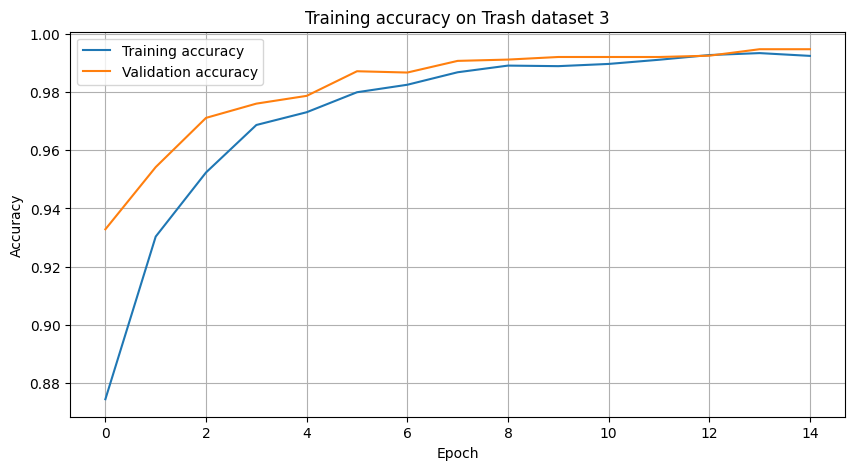

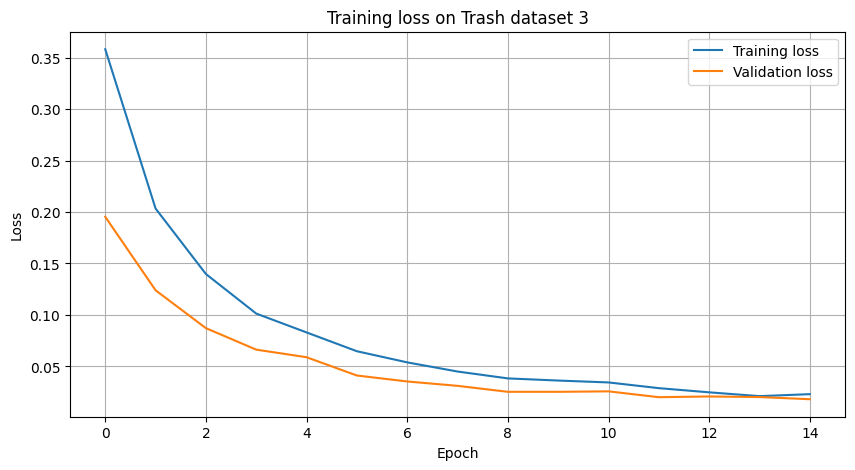

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Training accuracy on Trash dataset 3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training loss on Trash dataset 3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

We can see that the model trained very well on Trash dataset 3. The training and validation accuracy both increase quickly and become very high so almost 99%. This means the model is learning the waste categories well.

The loss also goes down strongly for both training and validation. This means the model is making fewer mistakes during training. Because the training and validation lines stay close to each other so it means that there is no overfitting.

#### 13.0 Precision, recall, F1-score and confusion matrix

Here I evaluate the model on the test set. I do not only look at accuracy because accuracy alone does not always show the full picture. For example, the model can be good overall but still weak for one specific category. That is also why I calculate precision, recall and F1-score. 
* Precision -> how often the model is correct when it predicts a certain class
* Recall -> how many real images of that class the model actually finds
* F1-score -> gives a balanced score between precision and recall


In [49]:
y_true = []
y_pred = []

for images, labels_batch in test_dataset:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

,precision,recall,f1-score,support
cardboard,0.993,1.000,0.997,450.000
glass,0.993,0.996,0.994,450.000
metal,0.996,0.996,0.996,450.000
paper,0.998,0.991,0.994,450.000
plastic,0.998,0.996,0.997,450.000
accuracy,0.996,0.996,0.996,0.996
macro avg,0.996,0.996,0.996,2250.000
weighted avg,0.996,0.996,0.996,2250.000


The total accuracy is 99.6% which means the model correctly predicts almost all test images. The precision, recall and F1-score are also very high for every class around 0.99% so the model performs well.

#### 14.0 Evaluation graph

In this graph I show precision, recall and F1-score for every waste category. 


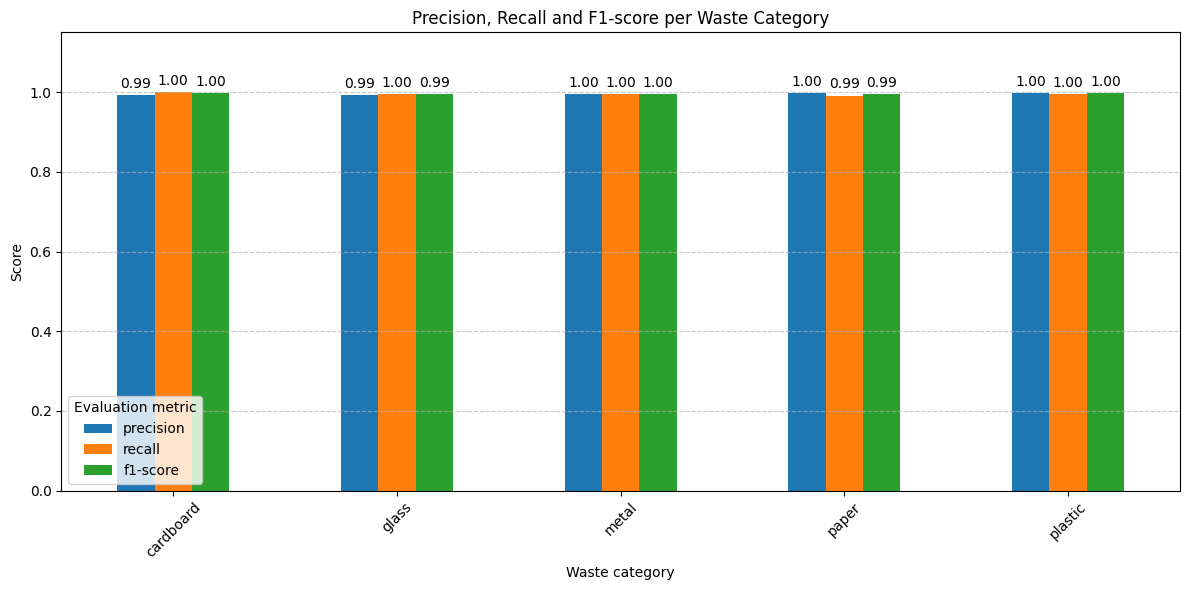

In [56]:
import matplotlib.pyplot as plt

#here it selects only the waste classes
metrics_df = report_df.loc[class_names, ["precision", "recall", "f1-score"]]

# creating the  bar chartchart 
ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1.15)
)

plt.title("Precision, Recall and F1-score per Waste Category")
plt.xlabel("Waste category")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Evaluation metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# values above the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

For all classes the precision, recall and F1-score are almost 1.00 this means the model is not only predicting the categories correctly but it is also doing this in a balanced way.

The results show:

* Cardboard is predicted very well with recall=1 => almost all cardboard images are found correctly.
* Glass also performs very well with small mistakes
* Metal has perfect scores all the evaluation matrixes are 1 so the model recognizes metal images very confidently
* Paper has a slightly lower recall= 0.99 and f1-score=0.99 compared to the others but the difference is very small
* Plastic also performs very well with very high precision, recall and F1-score which is 1

#### 15.0 Testing the model with one image

In this last part I test the model with one image from the test set. This is a practical check because it shows what the model predicts for a real image and how confident it is.

I show the true category, the predicted category and the confidence percentage. This helps me understand the result in a more human way, not only through tables and graphs. It also helps me see if the model prediction looks logical when I look at the image myself.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


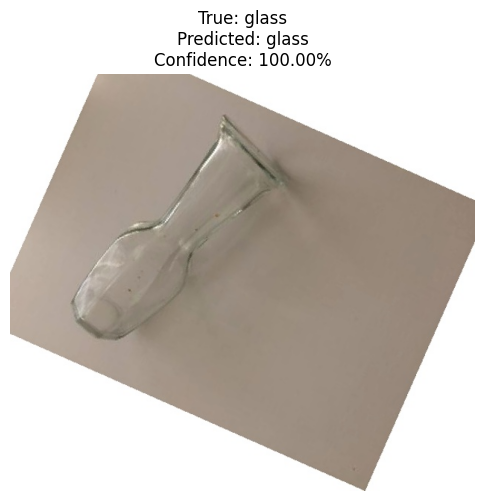

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# choosing the test image
example_image = test_paths[101]
true_label = test_labels[101]
true_class = class_names[true_label]


image = Image.open(example_image).convert("RGB")

# preprocess the image
image_array = np.array(image)
image_tensor = tf.convert_to_tensor(image_array)
image_tensor = tf.image.resize_with_pad(image_tensor, IMG_SIZE[0], IMG_SIZE[1])
image_tensor = tf.cast(image_tensor, tf.float32)
image_batch = tf.expand_dims(image_tensor, axis=0)

# predicting the category 
predictions = model.predict(image_batch)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[predicted_index] * 100

#visualisation
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"True: {true_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%",
    fontsize=12
)
plt.show()